# Cleaning and merging datasets

The goal of this notebook is to **merge the data** collected from API with the consolidated historical data obtained by running create_complete_hist_dataset.ipynb. Then, we **clean the data**, make sure the data is **qualitative** enough and plot the first graphs to have an **overview of the cleaned dataset**.

## Importations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import folium
from folium.plugins import MarkerCluster

In [2]:
# --- Loading historical data ---
path_historical_data = '/Users/quentingirard/Downloads/MCNDU_sorted_historical_dataset.csv'

if not os.path.exists(path_historical_data):
    raise FileNotFoundError(f"The historical file is not found at: {path_historical_data}")
hist_df = pd.read_csv(path_historical_data, sep=";", encoding="utf-8")

In [5]:
# --- Loading API data ---

### Must adapt this code for all the paths, as there is one file every 10 days

path_api_data_1 = '/Users/quentingirard/Desktop/Ecole/3A_Ponts/MCNDU/Projet-comptage-routier/petit-entrepot-pour-MCNDU/data/traffic_2025-12_1.parquet'
path_api_data_2 = '/Users/quentingirard/Desktop/Ecole/3A_Ponts/MCNDU/Projet-comptage-routier/petit-entrepot-pour-MCNDU/data/traffic_2025-12_2.parquet'

if not os.path.exists(path_api_data_1):
    raise FileNotFoundError(f"The API file is not found at: {path_api_data_1}")
api_df_1 = pd.read_parquet(path_api_data_1, engine='pyarrow')

if not os.path.exists(path_api_data_2):
    raise FileNotFoundError(f"The API file is not found at: {path_api_data_2}")
api_df_2 = pd.read_parquet(path_api_data_2, engine='pyarrow')
### Merging the two API datasets
api_df = pd.concat([api_df_1, api_df_2], ignore_index=True)
api_df = api_df.reset_index(drop=True)


## Cleaning raw data

**STEP 1:** Renaming, changing date format, droppping datapoints without position, extracting longitude and latitude

In [6]:
# --- 0 Useful functions ---

def get_lat_from_list(x):
    # Check if x is a list (or an array) and if it has at least 2 elements
    if isinstance(x, (list, np.ndarray)) and len(x) >= 2:
        return x[0]
    return None

def get_lon_from_list(x):
    if isinstance(x, (list, np.ndarray)) and len(x) >= 2:
        return x[1]
    return None

# --- 1. Historical Dataset ---
mapping_hist = {
    'Identifiant arc': 'Arc ID',
    'Libelle': 'Arc Name',
    'Date et heure de comptage': 'Datetime',
    'Débit horaire': 'Debit',
    'Taux d\'occupation': 'Occupation',
    'Etat trafic': 'Trafic',
    'Identifiant noeud amont': 'ID Upstream Node',
    'Libelle noeud amont': 'Upstream Node Name',
    'Identifiant noeud aval': 'ID Downstream Node',
    'Libelle noeud aval': 'Downstream Node Name',
    'Etat arc': 'Arc State',
    'Date debut dispo data': 'Start Date Available Data',
    'Date fin dispo data': 'End Date Available Data'
}

hist_df = hist_df.rename(columns=mapping_hist)

hist_df["Datetime"] = pd.to_datetime(hist_df["Datetime"], utc=True)

hist_df = hist_df.dropna(subset=['geo_point_2d']) #droping None values for geo_point_2d

hist_df['Latitude'] = hist_df['geo_point_2d'].apply(get_lat_from_list)
hist_df['Longitude'] = hist_df['geo_point_2d'].apply(get_lon_from_list)

hist_df.drop(columns=['geo_point_2d', 'geo_shape'], inplace=True, errors='ignore')

# --- 2. API Dataset ---

columns_mapping = {
    'iu_ac': 'Arc ID',
    'libelle': 'Arc Name',
    't_1h': 'Datetime',
    'q': 'Debit',               # q = débit (flow)
    'k': 'Occupation',          # k = taux d'occupation
    'etat_trafic': 'Trafic',
    'iu_nd_amont': 'ID Upstream Node',
    'libelle_nd_amont': 'Upstream Node Name',
    'iu_nd_aval': 'ID Downstream Node',
    'libelle_nd_aval': 'Downstream Node Name',
    'etat_barre': 'Arc State',
    'date_debut': 'Start Date Available Data',
    'date_fin': 'End Date Available Data'
}

api_df = api_df.rename(columns=columns_mapping)

api_df["Datetime"] = pd.to_datetime(api_df["Datetime"], utc=True)

api_df = api_df.dropna(subset=['geo_point_2d']) #droping None values

api_df['Latitude'] = api_df['geo_point_2d'].apply(get_lat_from_list)
api_df['Longitude'] = api_df['geo_point_2d'].apply(get_lon_from_list)

api_df.drop(columns=['geo_point_2d', 'geo_shape'], inplace=True, errors='ignore')

# Sorting by decreasing date (we don't do it for historical dataset as it is already sorted from create_complete_hist_dataset.ipynb)
api_df = api_df.sort_values(by="Datetime", ascending=False)

# --- 3. Verification ---
# hist_df.head()
# api_df.head()

**STEP 2:** Getting relevant datatypes for each feature

In [7]:
# --- 1. Historical Dataset ---

# Date Conversion
date_cols = ['End Date Available Data', 'Start Date Available Data']

for col in date_cols:
    hist_df[col] = pd.to_datetime(hist_df[col], errors='coerce')

# Integer Conversion
int_cols = ['Arc ID', 'ID Upstream Node', 'ID Downstream Node']

for col in int_cols:
    # Step 1: Force numeric conversion, errors become NaN
    hist_df[col] = pd.to_numeric(hist_df[col], errors='coerce')
    # Step 2: Convert to Integer type compatible with NaN
    hist_df[col] = hist_df[col].astype('Int64')

# String Conversion
str_cols = ['Arc Name', 'Trafic', 'Upstream Node Name', 'Downstream Node Name']

for col in str_cols:
    hist_df[col] = hist_df[col].astype('string')

# Binary Variables
mapping_state = {
    'Ouvert': 1,
    'Fermé': 0
}

hist_df['Arc State'] = hist_df['Arc State'].map(mapping_state)
hist_df['Arc State'] = hist_df['Arc State'].astype('Int64')

# --- 2. API Dataset ---

# Date conversion
date_cols = ['End Date Available Data', 'Start Date Available Data']

for col in date_cols:
    api_df[col] = pd.to_datetime(api_df[col], errors='coerce')

# Integer conversion
int_cols = ['Arc ID', 'ID Upstream Node', 'ID Downstream Node']

for col in int_cols:
    # Step 1: Force numeric conversion, errors become NaN
    api_df[col] = pd.to_numeric(api_df[col], errors='coerce')
    # Step 2: Convert to Integer type compatible with NaN
    api_df[col] = api_df[col].astype('Int64')

# String conversion
str_cols = ['Arc Name', 'Trafic', 'Upstream Node Name', 'Downstream Node Name']

for col in str_cols:
    api_df[col] = api_df[col].astype('string')

# Binary variables
mapping_state = {
    'Ouvert': 1,
    'Fermé': 0
}

api_df['Arc State'] = api_df['Arc State'].map(mapping_state)

api_df['Arc State'] = api_df['Arc State'].astype('Int64')

# --- 3. Verification ---
# print(hist_df.info())
# print(api_df.info())

## Merging the datasets

In [8]:
# We put api_df first in the list so it appears "on top"
full_df = pd.concat([api_df, hist_df], ignore_index=True)
full_df = full_df.reset_index(drop=True)

# --- Verification ---
print(f"--- Merge Complete ---")
print(f"Total shape: {full_df.shape}")
print(f"Date range: from {full_df['Datetime'].min()} to {full_df['Datetime'].max()}")

# Check for duplicates (optional but recommended when overlapping time ranges are possible)
duplicates = full_df.duplicated(subset=['Arc ID', 'Datetime']).sum()
print(f"Duplicate rows found (same ID and Time): {duplicates}")

#full_df.head()

/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_938/2822677555.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([api_df, hist_df], ignore_index=True)


--- Merge Complete ---
Total shape: (28551990, 15)
Date range: from 2024-10-01 03:00:00+00:00 to 2025-12-15 19:00:00+00:00
Duplicate rows found (same ID and Time): 0


## Uncomplete values analysis

Uncomplete data means either debit is missing or taux d'occupation is missing. 

**STEP 1:** We get a first overview of the uncomplete data

In [9]:
total_rows = len(full_df)

mask_debit_na = full_df['Debit'].isna()
mask_occ_na = full_df['Occupation'].isna()

# --- Calculations ---
count_any_missing = (mask_debit_na | mask_occ_na).sum()
count_only_debit_missing = (mask_debit_na & ~mask_occ_na).sum()
count_only_occ_missing = (mask_occ_na & ~mask_debit_na).sum()
count_both_missing = (mask_debit_na & mask_occ_na).sum()

# --- Displaying Percentages ---

print(f"Total data volume: {total_rows} rows\n")

print(f"At least one of the two values is missing (Total) : {count_any_missing / total_rows * 100:.2f}%")
print("-" * 60)
print(f"-> Of which only Debit is missing                 : {count_only_debit_missing / total_rows * 100:.2f}%")
print(f"-> Of which only Occupation is missing            : {count_only_occ_missing / total_rows * 100:.2f}%")
print(f"-> Of which BOTH are missing                      : {count_both_missing / total_rows * 100:.2f}%")

# Mathematical verification (the sum of the three sub-categories must equal the Total)
assert count_any_missing == (count_only_debit_missing + count_only_occ_missing + count_both_missing)

Total data volume: 28551990 rows

At least one of the two values is missing (Total) : 59.28%
------------------------------------------------------------
-> Of which only Debit is missing                 : 13.26%
-> Of which only Occupation is missing            : 10.72%
-> Of which BOTH are missing                      : 35.30%


**STEP 2:** We retrieve and drop all the bad quality stations (giving at least 5% of uncomplete data)

In [10]:
def get_low_quality_stations(df, threshold_percent):
    """
    Identifies stations ('Arc ID') that have a complete data rate below the given threshold.
    A data point is "complete" if 'Debit' (Flow) AND 'Occupation' are not NaN.
    
    Args:
        df (pd.DataFrame): The dataset containing 'Arc ID', 'Debit', 'Occupation'.
        threshold_percent (float): The minimum acceptable percentage (e.g., 95 for 95%).
        
    Returns:
        list: The list of 'Arc ID's that are below the threshold.
    """
    
    # 1. Create a boolean mask: True if the row is complete, False otherwise
    # ~ means NOT, .isna() checks for NaNs
    is_complete = ~df['Debit'].isna() & ~df['Occupation'].isna()
    
    # 2. Group by station and calculate the percentage of True values
    # The mean of booleans gives the ratio (e.g., 0.85). We multiply by 100.
    station_completeness = is_complete.groupby(df['Arc ID']).mean() * 100
    
    # 3. Filter stations below the threshold
    bad_stations = station_completeness[station_completeness < threshold_percent]
    
    # 4. Return the list of IDs (the index of the filtered series)
    return bad_stations.index.tolist()

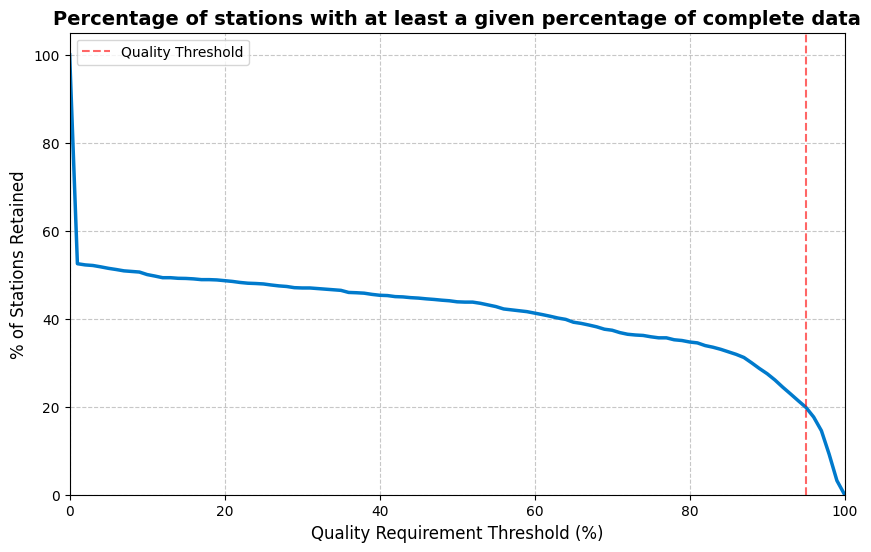

In [20]:
threshold = 95 #value in percent

# --- 1. Single calculation of scores per station ---
# Calculate the percentage of valid data for EACH station only once
is_complete = ~full_df['Debit'].isna() & ~full_df['Occupation'].isna()
station_scores = is_complete.groupby(full_df['Arc ID']).mean() * 100

total_stations = len(station_scores)

# --- 2. Data generation for the plot ---
thresholds = np.arange(0, 101, 1)
kept_stations_ratios = []

for t in thresholds:
    count_valid = (station_scores >= t).sum()
    
    ratio = (count_valid / total_stations) * 100
    kept_stations_ratios.append(ratio)

# --- 3. Plotting the curve ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, kept_stations_ratios, color='#007acc', linewidth=2.5)

plt.axvline(x= threshold, color='red', linestyle='--', alpha=0.6, label='Quality Threshold')

# Formatting
plt.title("Percentage of stations with at least a given percentage of complete data", fontsize=14, fontweight='bold')
plt.xlabel("Quality Requirement Threshold (%)", fontsize=12)
plt.ylabel("% of Stations Retained", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xlim(0, 100)
plt.ylim(0, 105)

plt.show()

In [21]:
# --- Dropping data from bad stations ---

bad_ids = get_low_quality_stations(full_df, threshold_percent=threshold)

# 1. Store the initial size for comparison
initial_rows = len(full_df)

# 2. Identify the rows to keep
# We keep rows where 'Arc ID' is NOT in the list of bad_ids.
full_df_clean = full_df[~full_df['Arc ID'].isin(bad_ids)].copy()

# 3. Calculate drop statistics
dropped_rows = initial_rows - len(full_df_clean)
dropped_stations = len(bad_ids)
final_rows = len(full_df_clean)

# 4. Display the summary
print(f"--- Quality-based Removal Summary ---")
print(f"Number of original stations: {len(full_df['Arc ID'].unique())}")
print(f"Low-quality stations dropped: {dropped_stations}")
print(f"Stations retained: {len(full_df_clean['Arc ID'].unique())}")
print("-" * 40)
print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows dropped: {dropped_rows}")
print(f"Final number of rows: {final_rows}")

--- Quality-based Removal Summary ---
Number of original stations: 2956
Low-quality stations dropped: 2369
Stations retained: 587
----------------------------------------
Initial number of rows: 28551990
Number of rows dropped: 22874955
Final number of rows: 5677035


**STEP 3:** Once we dropped all the datapoints from bad quality stations, we drop the remaining bad quality data from good quality stations (maximum 5% of remaining data with threshold = 95%)

In [22]:
# --- Dropping rows with missing traffic data ---

initial_rows = len(full_df_clean)
full_df_clean = full_df_clean.dropna(subset=['Debit', 'Occupation'])
final_rows = len(full_df_clean)

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after cleaning: {final_rows}")
print(f"Rows dropped: {initial_rows - final_rows}")

Initial number of rows: 5677035
Number of rows after cleaning: 5548232
Rows dropped: 128803


## Time-Range and Location Analysis to check the data is usable

**STEP 1:** We make sure the data flow is continuous over time (same number of datapoints per day)

Statistiques des entrées par jour (Excluant le 2025-12-15) :
--------------------------------------------------
Maximum      : 14079.00
Minimum      : 571.00
Moyenne      : 13375.34
Médiane      : 13853.50
Écart-type   : 2093.87
--------------------------------------------------


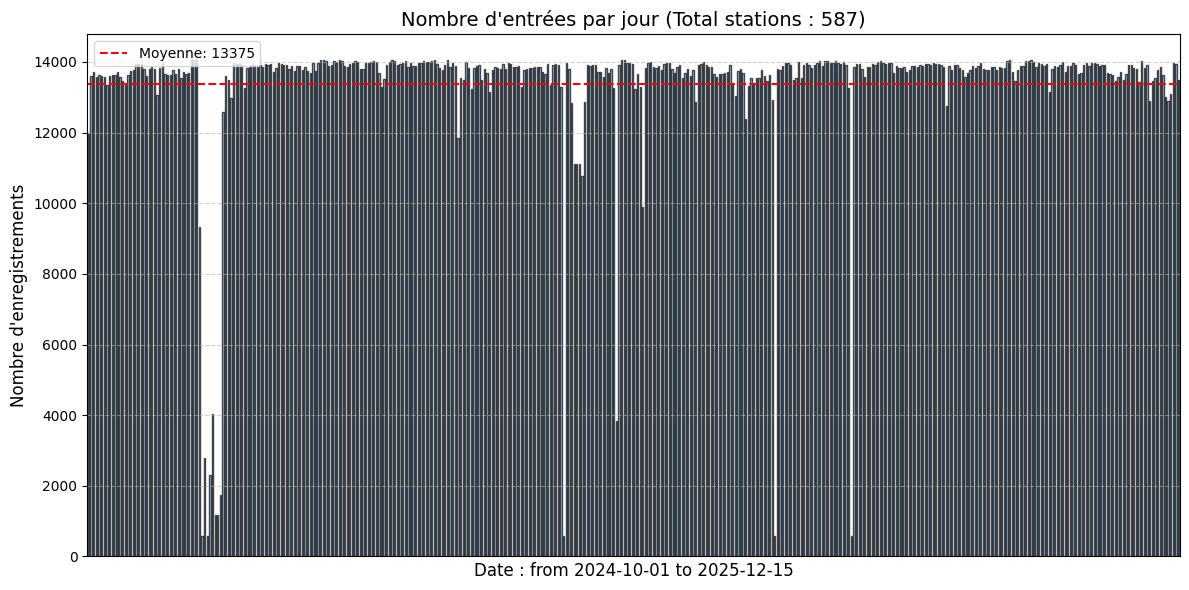

In [23]:
# Date extraction
full_df_clean['Date_Only'] = full_df_clean['Datetime'].dt.date

# Excluding the most recent day (potentially incomplete)
last_day = full_df_clean['Date_Only'].max()
df_final_plot = full_df_clean[full_df_clean['Date_Only'] < last_day]

# Computation
daily_counts = df_final_plot.groupby('Date_Only').size()

stats = {
    "Maximum": daily_counts.max(),
    "Minimum": daily_counts.min(),
    "Moyenne": daily_counts.mean(),
    "Médiane": daily_counts.median(),
    "Écart-type": daily_counts.std()
}

print(f"Statistiques des entrées par jour (Excluant le {last_day}) :")
print("-" * 50)
for key, value in stats.items():
    print(f"{key:12} : {value:.2f}")
print("-" * 50)

# Plotting 
plt.figure(figsize=(12, 6))
daily_counts.plot(kind='bar', color="#7bb7ef", edgecolor='black', alpha=0.7)

plt.axhline(stats["Moyenne"], color='red', linestyle='--', label=f'Moyenne: {stats["Moyenne"]:.0f}')
plt.title(f"Nombre d'entrées par jour (Total stations : {full_df_clean['Arc ID'].nunique()})", fontsize=14)
plt.xlabel(f"Date : from {full_df_clean['Date_Only'].min()} to {last_day}", fontsize=12)
plt.ylabel("Nombre d'enregistrements", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**STEP 2:** Location check : datapoints must be everywhere in Paris and we must not have any large zone without any data

In [24]:
location_data = full_df_clean.groupby(['Latitude', 'Longitude']).size().reset_index(name='counts')

# 1. Create the map centered on Paris
# We take the mean of latitudes/longitudes to center the map automatically
center_lat = location_data['Latitude'].mean()
center_lon = location_data['Longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron') 
# 'CartoDB positron' provides a clean, light-gray map background, ideal for highlighting colors.
# You can remove the 'tiles' argument to use the classic OpenStreetMap background.

# 2. Add the bubbles (CircleMarker)
for index, row in location_data.iterrows():
    
    # Size logic: divide by a factor to prevent overly large bubbles
    # Adjust the divisor (100 here) based on your actual data volume
    radius_size = row['counts'] / 100 
    
    # Ensure a minimum size (e.g., 3 pixels) so small points are visible
    if radius_size < 3:
        radius_size = 3

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=radius_size,
        popup=f"Volume: {row['counts']}", # Displays the count on click
        tooltip=f"Area: {row['counts']} measurements", # Displays on hover
        color='#FF4500',      # Border color (Orange Red)
        fill=True,
        fill_color='#FF4500', # Fill color
        fill_opacity=0.6      # Opacity to show overlapping areas
    ).add_to(m)

# 3. Display or save the map
# m.save("traffic_map_paris.html") # Saves to an HTML file (optional)
m